170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


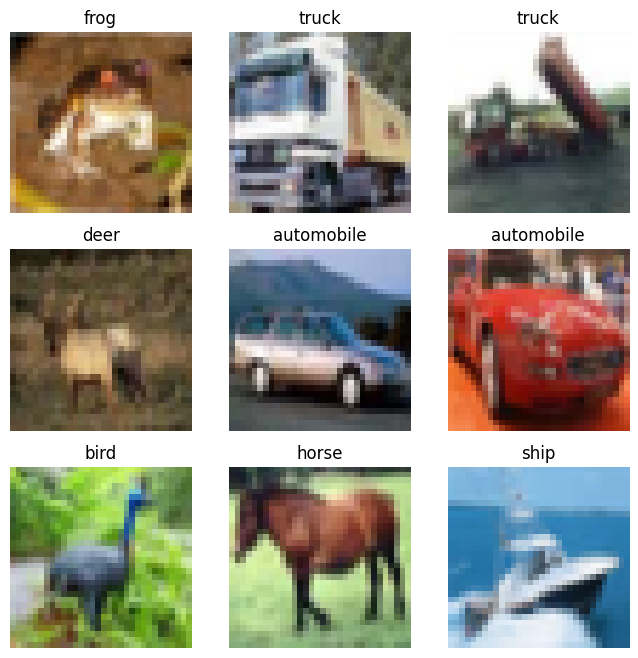

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 67s 41ms/step - accuracy: 0.4324 - loss: 1.5564 - val_accuracy: 0.5467 - val_loss: 1.2631
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 41ms/step - accuracy: 0.5768 - loss: 1.1919 - val_accuracy: 0.6137 - val_loss: 1.0875
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 64s 41ms/step - accuracy: 0.6394 - loss: 1.0311 - val_accuracy: 0.6480 - val_loss: 0.9907
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 63s 40ms/step - accuracy: 0.6727 - loss: 0.9305 - val_accuracy: 0.6599 - val_loss: 0.9760
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 41ms/step - accuracy: 0.6992 - loss: 0.8574 - val_accuracy: 0.6774 - val_loss: 0.9218
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 63s 41ms/step - accuracy: 0.7182 - loss: 0.8000 - val_accuracy: 0.6803 - val_loss: 0.9080
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 64s 41ms/step - accuracy: 0.7380 - loss: 0.7480 - val_accuracy: 0.6994 - val_loss: 0.8735
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 42ms/step - accuracy: 0.7533 -

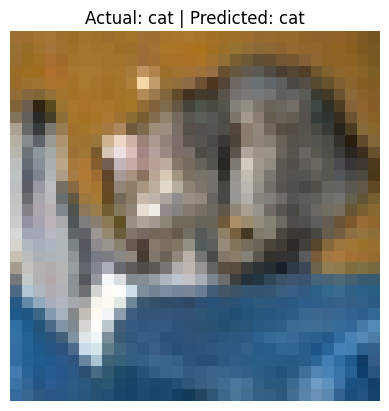

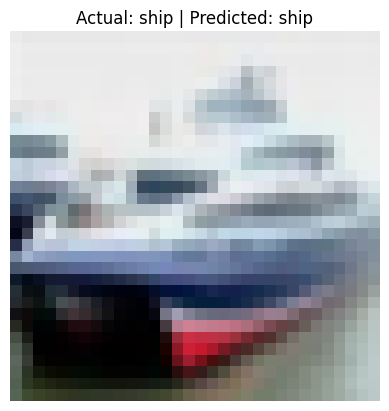

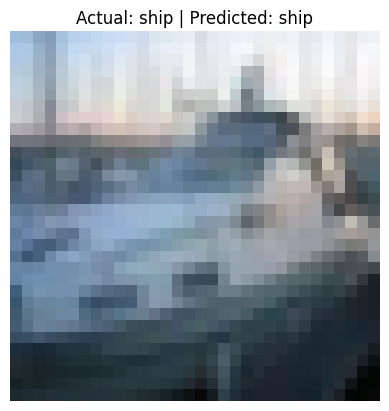

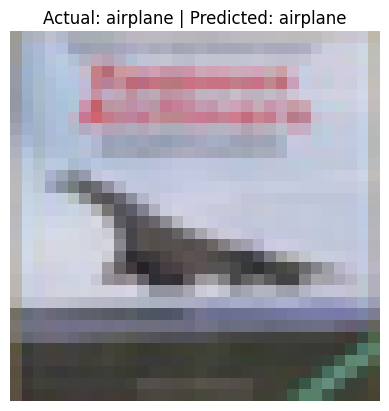

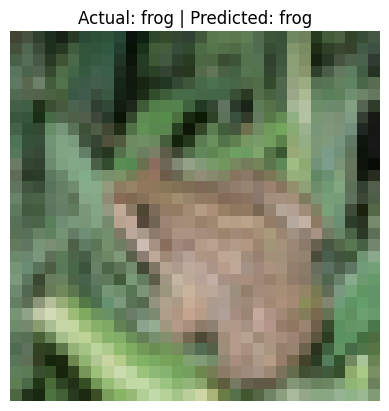

In [ ]:
# Case Study 2: CIFAR-10 Image Classification using CNN

import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

# 1. Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

# 2. Normalize pixel values
x_train = x_train / 255.0
x_test = x_test / 255.0

# 3. Class names
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# 4. Display sample images
plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.show()

# 5. Build CNN Model
model = models.Sequential()

model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64,(3,3),activation='relu'))

model.add(layers.Flatten())
model.add(layers.Dense(64,activation='relu'))
model.add(layers.Dense(10,activation='softmax'))

# 6. Compile Model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 7. Train Model
history = model.fit(x_train, y_train,
                    epochs=10,
                    validation_data=(x_test, y_test))

# 8. Evaluate Model
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

# 9. Predict some images
predictions = model.predict(x_test[:5])

for i in range(5):
    plt.imshow(x_test[i])
    plt.title("Actual: " + class_names[y_test[i][0]] +
              " | Predicted: " + class_names[np.argmax(predictions[i])])
    plt.axis('off')
    plt.show()